# Task 5: Sales Prediction Using Python

## Objective
Build a machine learning regression model to predict product sales based on advertising expenditure on TV, Radio, and Newspaper channels.

In [33]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [34]:
# Download the Advertising dataset

!wget -q https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [35]:
# Load the dataset

df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (200, 5)


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [36]:
# Explore the dataset

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Missing Values:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Statistical Summary:


,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the dataset, identify relationships between advertising channels and sales, and observe patterns before building the regression models.

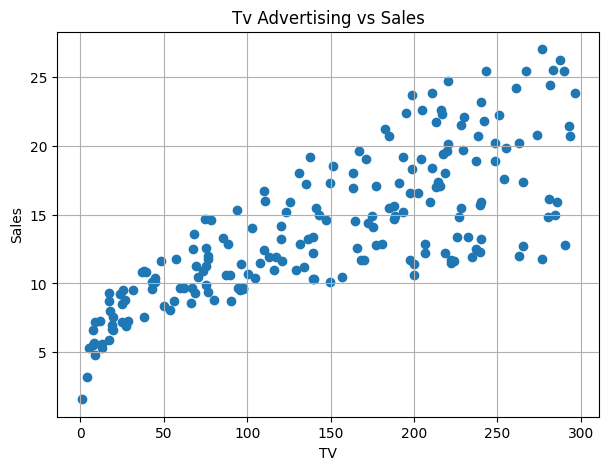

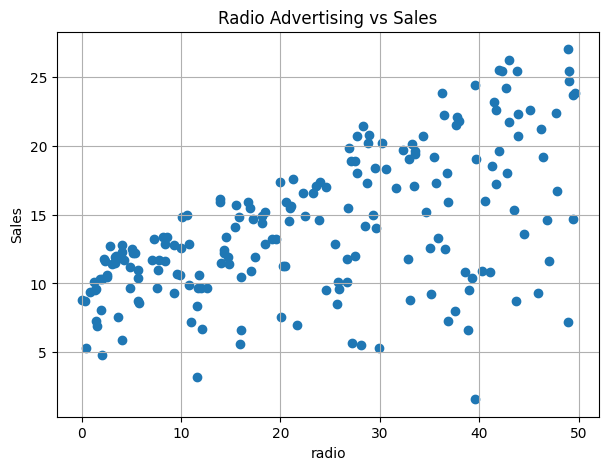

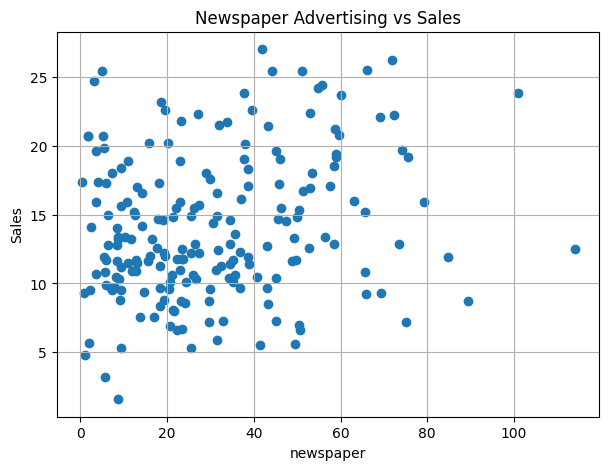

In [37]:
# Scatter plots: Advertising channels vs Sales

features = ["TV", "radio", "newspaper"]

for feature in features:
    plt.figure(figsize=(7, 5))
    plt.scatter(df[feature], df["sales"])
    plt.xlabel(feature)
    plt.ylabel("Sales")
    plt.title(f"{feature.capitalize()} Advertising vs Sales")
    plt.grid(True)
    plt.show()

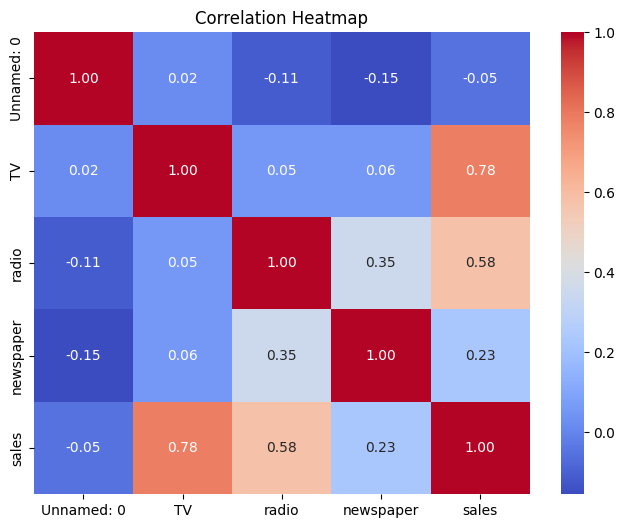

In [38]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [39]:
# Select features and target

X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target:


,sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9


In [40]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


In [41]:
# Train Linear Regression model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [42]:
# Train Random Forest Regression model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [43]:
# Make predictions using both models

y_pred_linear = linear_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [44]:
# Evaluate model performance

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression metrics
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

# Random Forest metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Linear Regression")
print("MAE :", round(mae_linear, 3))
print("RMSE:", round(rmse_linear, 3))
print("R²  :", round(r2_linear, 3))

print("\nRandom Forest Regression")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))

Linear Regression
MAE : 1.461
RMSE: 1.782
R²  : 0.899

Random Forest Regression
MAE : 0.62
RMSE: 0.769
R²  : 0.981


In [45]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R² Score": [r2_linear, r2_rf]
})

comparison.round(3)

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.461,1.782,0.899
1,Random Forest,0.620,0.769,0.981


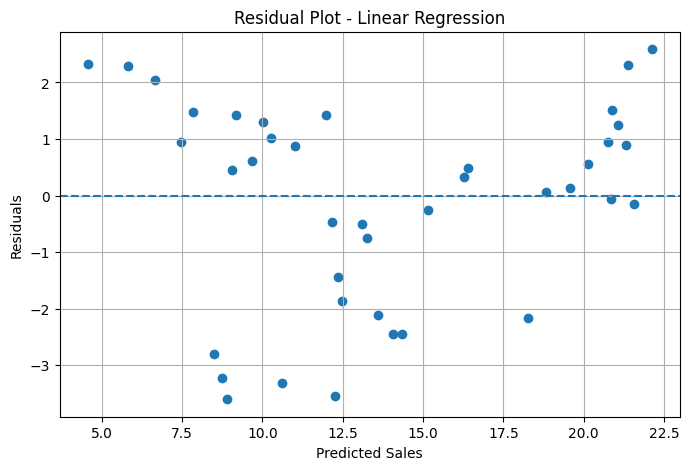

In [46]:
# Residual plot for Linear Regression

residuals = y_test - y_pred_linear

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_linear, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.grid(True)
plt.show()

In [47]:
# Feature coefficients from Linear Regression

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,radio,0.189195
2,newspaper,0.002761


,Feature,Importance
0,TV,0.624810
1,radio,0.362201
2,newspaper,0.012989


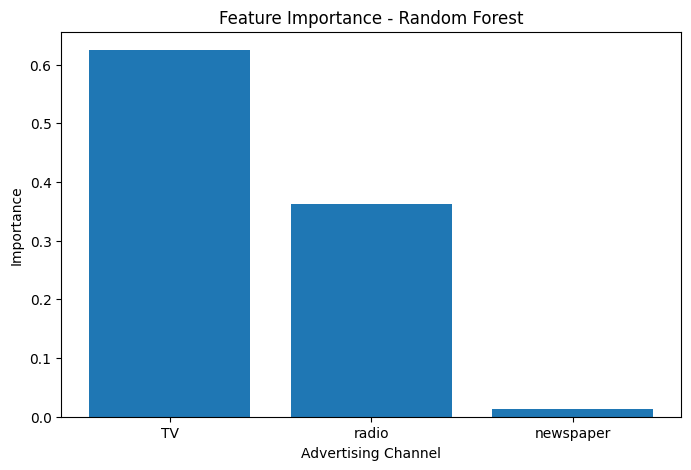

In [48]:
# Feature importance from Random Forest

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)

plt.figure(figsize=(8, 5))
plt.bar(importance["Feature"], importance["Importance"])
plt.xlabel("Advertising Channel")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

# Conclusion

The Sales Prediction project successfully used machine learning regression techniques to predict sales based on advertising expenditure.

Two models were trained and evaluated:
- Linear Regression
- Random Forest Regression

The models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The analysis showed that advertising expenditure has a measurable relationship with sales. The model with the lower error values and higher R² score provides better predictive performance on the test data.

Feature coefficients and feature importance were also analyzed to understand the contribution of TV, Radio, and Newspaper advertising to sales prediction.